# LoRA Fine-Tuning with FLAN-T5 and Hugging Face PEFT

## WMT16 English-to-German translation solution

This version uses PyTorch, PEFT, and `Seq2SeqTrainer`. It removes TensorFlow/Keras APIs, manual decoder inputs, custom layer replacement, and fixed-length TensorFlow dataset conversion.

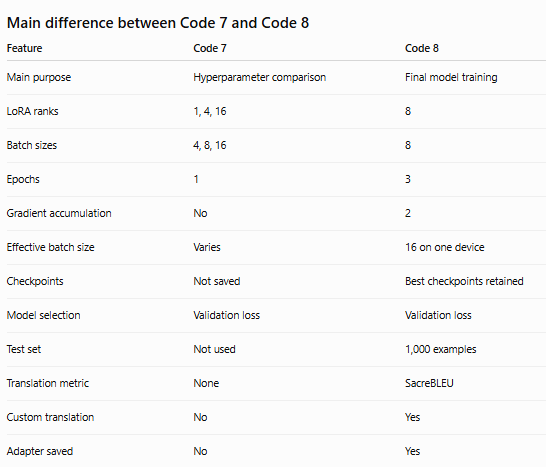

## 1. Install dependencies

In [ ]:
# Remove optional packages that commonly conflict with current
# PyTorch, Transformers, and PEFT installations in Colab.
!pip uninstall -y torchvision torchao

# Install the text-model and LoRA dependencies.
# Do not reinstall torch because Colab already provides it.
!pip install -q -U \
    transformers \
    datasets \
    peft \
    accelerate \
    evaluate \
    sacrebleu \
    sentencepiece

Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 8.6 MB/s eta 0:00:00


## 2. Check the environment

In [ ]:
import os
import random
import numpy as np
import torch
import transformers
import datasets
import peft

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("PEFT:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Transformers: 5.14.1
Datasets: 5.0.1
PEFT: 0.20.0
CUDA available: True


## 3. Load WMT16 and create training subsets

In [ ]:
from datasets import load_dataset

SEED = 42

TRAIN_SAMPLES = 20_000
VALIDATION_SAMPLES = 1_000
TEST_SAMPLES = 1_000

train_raw = load_dataset(
    "wmt/wmt16",
    "de-en",
    split=f"train[:{TRAIN_SAMPLES}]"
).shuffle(seed=SEED)

validation_raw = load_dataset(
    "wmt/wmt16",
    "de-en",
    split=f"validation[:{VALIDATION_SAMPLES}]"
).shuffle(seed=SEED)

test_raw = load_dataset(
    "wmt/wmt16",
    "de-en",
    split=f"test[:{TEST_SAMPLES}]"
).shuffle(seed=SEED)

print("Training dataset:", train_raw)
print("Validation dataset:", validation_raw)
print("Test dataset:", test_raw)

print("\nFirst training example:")
print(train_raw[0])

README.md:   0%|          | 0.00/11.1k [00:00<?, ?B/s]

de-en/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  282MB            

de-en/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

de-en/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  267MB            

de-en/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

de-en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/4548885 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2999 [00:00<?, ? examples/s]

Training dataset: Dataset({
    features: ['translation'],
    num_rows: 20000
})
Validation dataset: Dataset({
    features: ['translation'],
    num_rows: 1000
})
Test dataset: Dataset({
    features: ['translation'],
    num_rows: 1000
})

First training example:
{'translation': {'de': 'Wir müssen zeigen, welche Probleme wir gelöst und für welche wir noch keine Lösung gefunden haben.', 'en': 'We need to make it evident which problems we are solving and which we have not yet solved.'}}


## 4. Load FLAN-T5 and preprocess translation pairs

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-base"
MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print("Base-model parameters:", f"{base_model.num_parameters():,}")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Base-model parameters: 247,577,856


In [ ]:
def preprocess_batch(examples):
    inputs = [
        f"translate English to German: {pair['en']}"
        for pair in examples["translation"]
    ]
    targets = [pair["de"] for pair in examples["translation"]]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )
    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=train_raw.column_names,
    desc="Tokenizing training data",
)
validation_dataset = validation_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=validation_raw.column_names,
    desc="Tokenizing validation data",
)
test_dataset = test_raw.map(
    preprocess_batch,
    batched=True,
    remove_columns=test_raw.column_names,
    desc="Tokenizing test data",
)

print(train_dataset.column_names)

Tokenizing training data:   0%|          | 0/20000 [00:00<?, ? examples/s]

Tokenizing validation data:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing test data:   0%|          | 0/1000 [00:00<?, ? examples/s]

['input_ids', 'attention_mask', 'labels']


## 5. Add LoRA adapters

In [ ]:
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q", "v"],
    bias="none",
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561


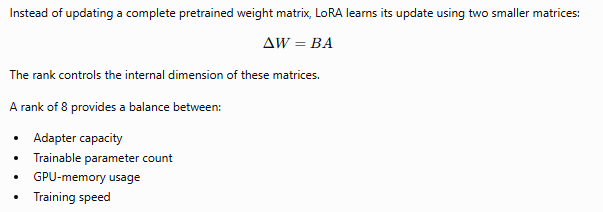

## 6. Count trainable and frozen parameters

In [ ]:
total_parameters = sum(parameter.numel() for parameter in model.parameters())
trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters()
    if parameter.requires_grad
)
frozen_parameters = total_parameters - trainable_parameters

print(f"Total parameters:       {total_parameters:,}")
print(f"Trainable parameters:   {trainable_parameters:,}")
print(f"Frozen parameters:      {frozen_parameters:,}")
print(f"Trainable percentage:   {100 * trainable_parameters / total_parameters:.4f}%")

Total parameters:       248,462,592
Trainable parameters:   884,736
Frozen parameters:      247,577,856
Trainable percentage:   0.3561%


## 7. Configure and train with Seq2SeqTrainer

In [ ]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments

USE_BF16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
USE_FP16 = torch.cuda.is_available() and not USE_BF16

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

training_args = Seq2SeqTrainingArguments(
    output_dir="./chapter4_solution_lora_translation",
    num_train_epochs=3,
    learning_rate=5e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,
    fp16=USE_FP16,
    bf16=USE_BF16,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,4.835520,2.366518
2,4.783921,2.362241
3,4.767697,2.361642


TrainOutput(global_step=3750, training_loss=4.873757397460937, metrics={'train_runtime': 1326.5491, 'train_samples_per_second': 45.23, 'train_steps_per_second': 2.827, 'total_flos': 5672079095316480.0, 'train_loss': 4.873757397460937, 'epoch': 3.0})

## 8. Evaluate loss and corpus BLEU

In [ ]:
print(trainer.evaluate())

Training Loss,Validation Loss,Epoch
4.767697,2.361642,3


{'eval_loss': 2.3616416454315186}


In [ ]:
import sacrebleu #Imports SacreBLEU, a standardized implementation of the BLEU translation metric.

# predict_with_generate=True makes these generated integer token IDs,
# rather than floating-point vocabulary logits.
prediction_output = trainer.predict(
    test_dataset,
    max_length=MAX_TARGET_LENGTH,
    num_beams=4,
)
predictions = prediction_output.predictions
labels = prediction_output.label_ids

if isinstance(predictions, tuple):
    predictions = predictions[0]

predictions = np.asarray(predictions)
labels = np.asarray(labels)

if predictions.ndim != 2:
    raise ValueError(
        f"Expected generated token IDs with shape (examples, sequence_length), "
        f"but received {predictions.shape}. Ensure predict_with_generate=True."
    )

predictions = np.where(predictions >= 0, predictions, tokenizer.pad_token_id).astype(np.int64)
labels = np.where(labels != -100, labels, tokenizer.pad_token_id).astype(np.int64)

predicted_texts = [text.strip() for text in tokenizer.batch_decode(predictions, skip_special_tokens=True)]
reference_texts = [text.strip() for text in tokenizer.batch_decode(labels, skip_special_tokens=True)]

bleu = sacrebleu.corpus_bleu(predicted_texts, [reference_texts])
print(f"BLEU score on test subset: {bleu.score:.2f}")

for i in range(min(5, len(predicted_texts))):
    source = tokenizer.decode(test_dataset[i]["input_ids"], skip_special_tokens=True)
    print(f"\nInput: {source}")
    print(f"Reference: {reference_texts[i]}")
    print(f"Prediction: {predicted_texts[i]}")

BLEU score on test subset: 16.76

Input: translate English to German: PHE has a clear duty to inform the public about what the evidence shows and what it does not show, especially when there was so much public confusion about the relative dangers compared to tobacco.
Reference: PHE hat die eindeutige Pflicht zur Information der ffentlichkeit über das, was der Nachweis belegt und was nicht, vor allem, wenn es soviel öffentliche Verwirrung über die relativen Gefahren im Vergleich zum Tabak gibt.
Prediction: Die PHE hat eine klare Pflicht, die ffentlichkeit darüber zu informieren, was die Beweise zeigt und nicht zeigt, vor allem wenn es so viele ffentlichkeitskonzentrationen über die relativen Gefahren gegenüber Tabak geführt hat.

Input: translate English to German: They may dimly remember Boris Johnson, the arch Euro-opportunist, making his name as an "EU straight bananas" Brussels correspondent in the early 90s.
Reference: Sie können sich schwach an Boris Johnson, den Erz-Euro-Opportun

## 9. Translate a new sentence

In [ ]:
def translate(text, max_new_tokens=128):
    model.eval()
    device = next(model.parameters()).device
    encoded = tokenizer(
        f"translate English to German: {text}",
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_LENGTH,
    ).to(device)

    with torch.inference_mode():
        generated = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
        )

    return tokenizer.decode(generated[0], skip_special_tokens=True)

print(translate("Machine learning is useful for solving many practical problems."))

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Machine Lernen ist nützlich für die Lösung zahlreicher praktischen Probleme.


## 10. Save the LoRA adapter

In [ ]:
ADAPTER_DIR = "./chapter4_solution_lora_adapter"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Adapter saved to", ADAPTER_DIR)

Adapter saved to ./chapter4_solution_lora_adapter
